<a href="https://colab.research.google.com/github/Pornphankub/BSC_DPDM2025/blob/main/Ch5_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data

In [1]:
from sklearn.datasets import load_digits

# Load the digits dataset (a common representation of MNIST in sklearn)
digits = load_digits()

# You can access the data and target with:
X = digits.data
y = digits.target

print("Dataset loaded successfully.")
print(f"Number of samples: {digits.data.shape[0]}")
print(f"Number of features per sample: {digits.data.shape[1]}")
print(f"Shape of data : {X.shape} ")
print(f"Shape of target: {y.shape}")

Dataset loaded successfully.
Number of samples: 1797
Number of features per sample: 64
Shape of data : (1797, 64) 
Shape of target: (1797,)


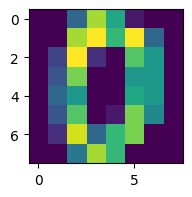

In [2]:
import matplotlib.pyplot as plt

first_image = X[0]
first_label = y[0]

plt.figure(figsize=(2,2))
plt.imshow(first_image.reshape(8,8))

First Image Data (8x8 array):
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]

First Target Label: 0


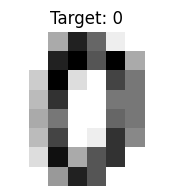

In [3]:

# Get the first image (data) and its target label
first_image_data = digits.images[0]
first_target_label = digits.target[0]

print(f"First Image Data (8x8 array):\n{first_image_data}")
print(f"\nFirst Target Label: {first_target_label}")

# To visualize the first image, you can use matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 2))
plt.imshow(first_image_data, cmap=plt.cm.gray_r, interpolation='nearest')
plt.title(f'Target: {first_target_label}')
plt.axis('off')
plt.show()

In [4]:
import pandas as pd

df = pd.DataFrame(X)

df['target'] = digits.target


print("Dataframe : ", df.shape)

Dataframe :  (1797, 65)


In [5]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [6]:
X_train = X[:1700]
y_train = y[:1700]
X_test = X[1700:]
y_test = y[1700:]

# model construction


*   import
*   define (hyper-parameters)
*   train (fitting)
*   evaluate (train vs test)




# import

In [7]:
from sklearn.tree import DecisionTreeClassifier

# define

In [8]:
tree0 = DecisionTreeClassifier(random_state=6, min_samples_split=25,min_samples_leaf=2)

# Training

In [9]:
tree0.fit(X_train,y_train)

DecisionTreeClassifier(min_samples_leaf=2, min_samples_split=25, random_state=6)

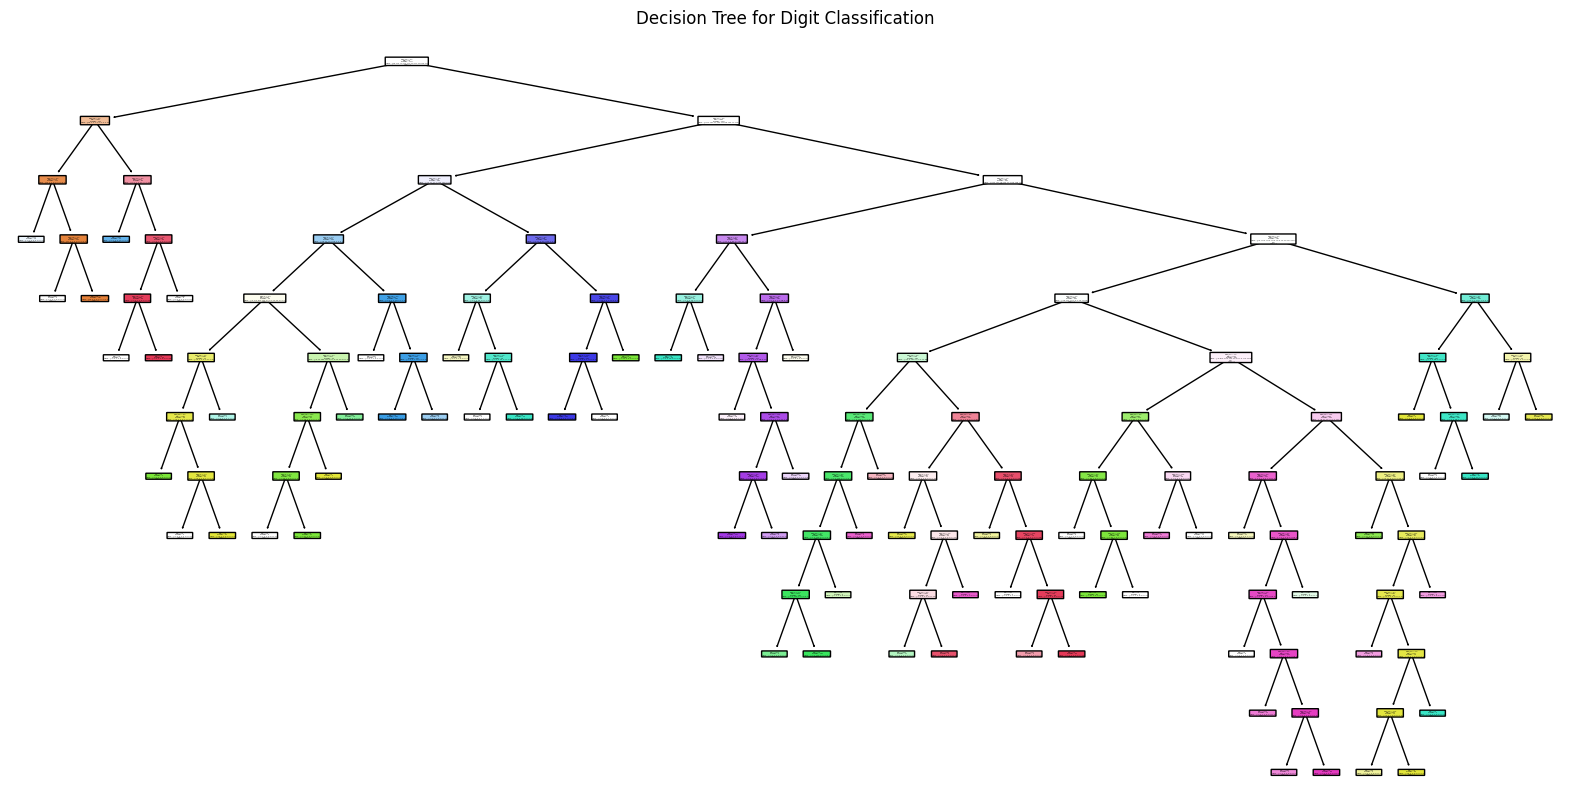

In [10]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10)) # Adjust figure size for better visibility
plot_tree(tree0, filled=True, rounded=True, class_names=[str(i) for i in range(10)], feature_names=[f'pixel_{i}' for i in range(X_train.shape[1])])
plt.title('Decision Tree for Digit Classification')
plt.show()

# Evaluate

In [11]:
y_predict = tree0.predict(X_test)

In [12]:
y_predict

array([9, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7, 7, 1, 5, 1, 0, 0, 5, 2, 7, 8, 2,
       0, 1, 2, 6, 8, 3, 7, 4, 3, 4, 6, 6, 6, 4, 9, 1, 1, 0, 9, 5, 7, 8,
       2, 0, 0, 4, 7, 6, 3, 2, 1, 7, 4, 6, 3, 1, 2, 9, 1, 7, 6, 8, 4, 9,
       1, 4, 0, 5, 3, 6, 9, 6, 1, 7, 5, 4, 4, 7, 2, 8, 2, 1, 5, 7, 9, 4,
       4, 8, 1, 4, 9, 0, 8, 9, 8])

In [13]:
y_test

array([5, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7, 7, 3, 5, 1, 0, 0, 2, 2, 7, 8, 2,
       0, 1, 2, 6, 3, 3, 7, 3, 3, 4, 6, 6, 6, 4, 9, 1, 5, 0, 9, 5, 2, 8,
       2, 0, 0, 1, 7, 6, 3, 2, 1, 7, 4, 6, 3, 1, 3, 9, 1, 7, 6, 8, 4, 3,
       1, 4, 0, 5, 3, 6, 9, 6, 1, 7, 5, 4, 4, 7, 2, 8, 2, 2, 5, 7, 9, 5,
       4, 8, 8, 4, 9, 0, 8, 9, 8])

In [14]:
from sklearn.metrics import accuracy_score

In [15]:
accuracy_score(y_test,y_predict)

0.865979381443299

Pre-pruning (hyper-parameter tuning)

In [16]:
from sklearn.tree import DecisionTreeClassifier
tree1 = DecisionTreeClassifier(random_state=6,max_depth=3)
tree1.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=6)

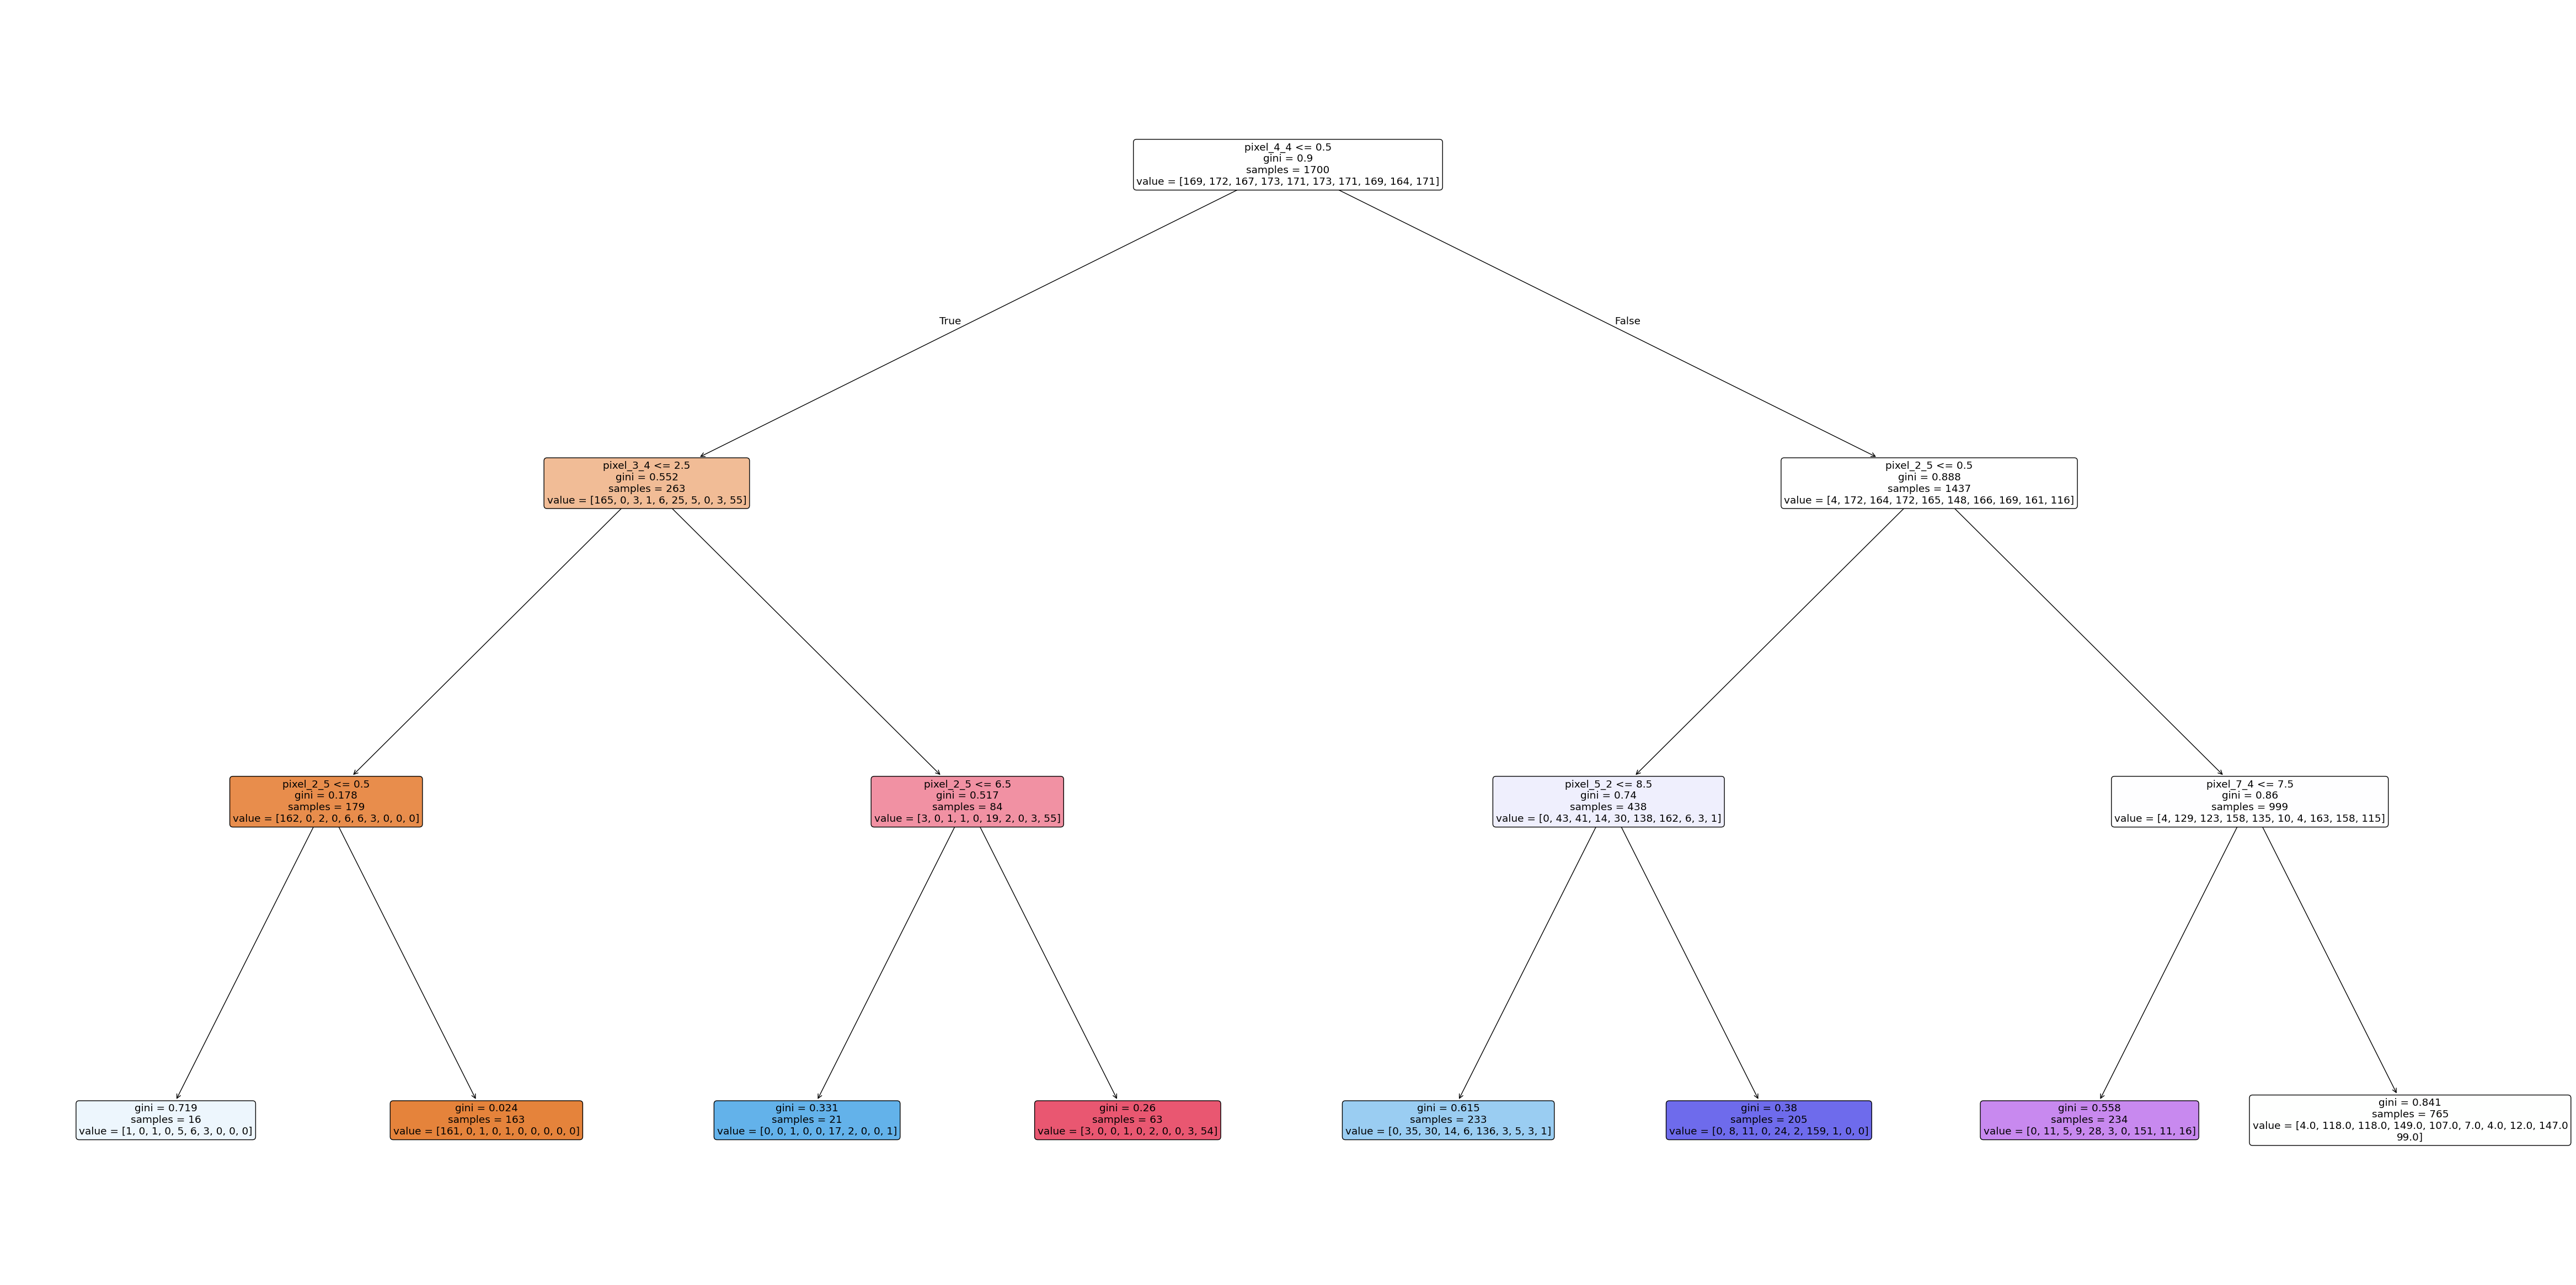

In [17]:
plt.figure(figsize=(60,30))
plot_tree(tree1, feature_names=digits.feature_names, filled=True , rounded=True )
plt.show()

# Evaluate

In [23]:
y_predict1 = tree1.predict(X_test)
accuracy_score(y_test,y_predict1)

0.4639175257731959

#Tuning parameter

In [24]:
tree2 = DecisionTreeClassifier(criterion="entropy",min_impurity_decrease=0,min_samples_split=2,ccp_alpha=0.00, random_state=6,)
tree2.fit(X_train,y_train)
accuray_score(y_test,tree2.predict(X_test))

NameError: name 'accuray_score' is not defined

# Quiz 11

In [19]:
tree3 = DecisionTreeClassifier(random_state=6,min_samples_leaf=2,min_samples_split=25)

In [20]:
tree3.fit(X_train,y_train)

DecisionTreeClassifier(min_samples_leaf=2, min_samples_split=25, random_state=6)

In [21]:
y_predict3 = tree3.predict(X_test)
accuracy_score(y_test,y_predict)

0.865979381443299

# Task
Perform a stratified train-test split on the dataset, then apply Grid Search with 10-fold stratified cross-validation to optimize both `KNeighborsClassifier` and `DecisionTreeClassifier` models. Finally, compare the best performing models from each algorithm and evaluate the overall best model on the unseen test set using accuracy.

## Stratified Train-Test Split

### Subtask:
Split the dataset into training and testing sets while preserving the class distribution in both splits using `stratify`.


**Reasoning**:
The subtask requires splitting the dataset into training and testing sets using stratified sampling to maintain class distribution. This step involves importing the necessary function, performing the split with specified parameters, and verifying the shapes of the resulting datasets.



In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1437, 64)
Shape of X_test: (360, 64)
Shape of y_train: (1437,)
Shape of y_test: (360,)


## Define Models and Parameter Grids

### Subtask:
Define `KNeighborsClassifier` and `DecisionTreeClassifier` models, along with their respective parameter grids for Grid Search.


**Reasoning**:
To define the models and their parameter grids, I will import `KNeighborsClassifier` and `DecisionTreeClassifier`, create instances of each, and then define their respective parameter grids as dictionaries.



In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Define KNeighborsClassifier and its parameter grid
knn = KNeighborsClassifier()
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11]
}

# Define DecisionTreeClassifier and its parameter grid
dtree = DecisionTreeClassifier(random_state=42)
dtree_param_grid = {
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6]
}

print("KNeighborsClassifier and its parameter grid defined.")
print("DecisionTreeClassifier and its parameter grid defined.")

KNeighborsClassifier and its parameter grid defined.
DecisionTreeClassifier and its parameter grid defined.


**Reasoning**:
Now that the models and their parameter grids are defined, the next step is to perform Grid Search with 10-fold stratified cross-validation for each model to find the best hyperparameters. This involves importing `GridSearchCV` and `StratifiedKFold`, then creating a `GridSearchCV` object for each model.



In [27]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define stratified 10-fold cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Setup GridSearchCV for KNeighborsClassifier
grid_knn = GridSearchCV(estimator=knn, param_grid=knn_param_grid, cv=skf, scoring='accuracy', n_jobs=-1, verbose=1)

# Setup GridSearchCV for DecisionTreeClassifier
grid_dtree = GridSearchCV(estimator=dtree, param_grid=dtree_param_grid, cv=skf, scoring='accuracy', n_jobs=-1, verbose=1)

print("GridSearchCV objects with StratifiedKFold defined for both models.")

GridSearchCV objects with StratifiedKFold defined for both models.


**Reasoning**:
The next step is to execute the Grid Search for both models by fitting them to the training data. This will search for the best hyperparameters for each model.



In [28]:
print("Starting Grid Search for KNeighborsClassifier...")
grid_knn.fit(X_train, y_train)
print("Grid Search for KNeighborsClassifier completed.")

print("Starting Grid Search for DecisionTreeClassifier...")
grid_dtree.fit(X_train, y_train)
print("Grid Search for DecisionTreeClassifier completed.")

print("Best parameters for KNeighborsClassifier:", grid_knn.best_params_)
print("Best accuracy for KNeighborsClassifier:", grid_knn.best_score_)

print("Best parameters for DecisionTreeClassifier:", grid_dtree.best_params_)
print("Best accuracy for DecisionTreeClassifier:", grid_dtree.best_score_)

Starting Grid Search for KNeighborsClassifier...
Fitting 10 folds for each of 5 candidates, totalling 50 fits
Grid Search for KNeighborsClassifier completed.
Starting Grid Search for DecisionTreeClassifier...
Fitting 10 folds for each of 80 candidates, totalling 800 fits
Grid Search for DecisionTreeClassifier completed.
Best parameters for KNeighborsClassifier: {'n_neighbors': 3}
Best accuracy for KNeighborsClassifier: 0.986771561771562
Best parameters for DecisionTreeClassifier: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best accuracy for DecisionTreeClassifier: 0.851791958041958


**Reasoning**:
Now that both models have been optimized using Grid Search, I will compare their best cross-validation scores to identify the overall best model. Then, I will evaluate this best model on the unseen test set to report its final accuracy.



In [29]:
best_knn_model = grid_knn.best_estimator_
best_dtree_model = grid_dtree.best_estimator_

knn_test_accuracy = best_knn_model.score(X_test, y_test)
dtree_test_accuracy = best_dtree_model.score(X_test, y_test)

print(f"KNeighborsClassifier Test Accuracy: {knn_test_accuracy}")
print(f"DecisionTreeClassifier Test Accuracy: {dtree_test_accuracy}")

if knn_test_accuracy > dtree_test_accuracy:
    overall_best_model = best_knn_model
    overall_best_accuracy = knn_test_accuracy
    model_name = "KNeighborsClassifier"
else:
    overall_best_model = best_dtree_model
    overall_best_accuracy = dtree_test_accuracy
    model_name = "DecisionTreeClassifier"

print(f"\nThe overall best model is {model_name} with a test accuracy of {overall_best_accuracy}")

KNeighborsClassifier Test Accuracy: 0.9861111111111112
DecisionTreeClassifier Test Accuracy: 0.825

The overall best model is KNeighborsClassifier with a test accuracy of 0.9861111111111112


## Summary:

### Data Analysis Key Findings

*   The dataset was successfully split into training (1437 samples, 80%) and testing (360 samples, 20%) sets using stratified sampling, ensuring class distribution was preserved.
*   Grid Search with 10-fold stratified cross-validation was applied to optimize two models: `KNeighborsClassifier` and `DecisionTreeClassifier`.
*   The best `KNeighborsClassifier` achieved a cross-validation accuracy of approximately 98.68% with `n_neighbors=3`.
*   The best `DecisionTreeClassifier` achieved a cross-validation accuracy of approximately 85.18% with `max_depth=None`, `min_samples_leaf=1`, and `min_samples_split=2`.
*   Upon evaluation on the unseen test set, the best `KNeighborsClassifier` achieved an accuracy of approximately 98.61%.
*   On the same test set, the best `DecisionTreeClassifier` achieved an accuracy of 82.5%.
*   The `KNeighborsClassifier` was identified as the overall best performing model with a test accuracy of approximately 98.61%.

### Insights or Next Steps

*   The `KNeighborsClassifier` significantly outperforms the `DecisionTreeClassifier` on this dataset, suggesting that the data's underlying structure is well-suited for distance-based classification.
*   Consider exploring more advanced ensemble methods like Random Forest or Gradient Boosting, which might capture complex relationships while potentially maintaining or improving upon the high accuracy achieved by KNN.


# Task Aj.tohn
Perform a stratified train-test split on the `X` and `y` data, followed by setting up a 10-fold stratified cross-validation. Define and train a K-Nearest Neighbors and a Decision Tree classifier, tuning their hyperparameters using a grid search with cross-validation. Finally, identify the best performing model based on accuracy, retrain it, and evaluate its accuracy on the unseen test set.

## Stratified Train-Test Split

### Subtask:
Perform a train-test split on the dataset (X, y) ensuring that both the training and test sets have the same class distribution. The resulting splits should be X_train, X_test, y_train, and y_test.


**Reasoning**:
To perform a stratified train-test split, I need to import the `train_test_split` function from `sklearn.model_selection` and then apply it to the `X` and `y` data with the specified parameters.



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1437, 64)
Shape of X_test: (360, 64)
Shape of y_train: (1437,)
Shape of y_test: (360,)


**Reasoning**:
To set up a 10-fold stratified cross-validation, I need to import `StratifiedKFold` from `sklearn.model_selection` and then initialize it with the desired number of splits and `random_state` for reproducibility, using `shuffle=True` to ensure randomness in folds.



In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Stratified K-Fold cross-validation splitter initialized.")

Stratified K-Fold cross-validation splitter initialized.


**Reasoning**:
To define and train a K-Nearest Neighbors classifier and tune its hyperparameters, I will import `KNeighborsClassifier` and `GridSearchCV`, define a parameter grid for `KNeighborsClassifier`, and then use `GridSearchCV` with `skf` for cross-validation.



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Define the K-Nearest Neighbors classifier
knn = KNeighborsClassifier()

# Define the parameter grid for KNN
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Set up GridSearchCV for KNN
knn_grid_search = GridSearchCV(knn, knn_param_grid, cv=skf, scoring='accuracy', n_jobs=-1, verbose=1)

# Train the KNN model with grid search
knn_grid_search.fit(X_train, y_train)

print(f"Best parameters for KNN: {knn_grid_search.best_params_}")
print(f"Best accuracy for KNN: {knn_grid_search.best_score_:.4f}")

Fitting 10 folds for each of 20 candidates, totalling 200 fits
Best parameters for KNN: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best accuracy for KNN: 0.9875


**Reasoning**:
To define and train a Decision Tree classifier and tune its hyperparameters, I will import `DecisionTreeClassifier`, define a parameter grid for it, and then use `GridSearchCV` with `skf` for cross-validation.



In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Define the Decision Tree classifier
dt = DecisionTreeClassifier(random_state=42)

# Define the parameter grid for Decision Tree
dt_param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Set up GridSearchCV for Decision Tree
dt_grid_search = GridSearchCV(dt, dt_param_grid, cv=skf, scoring='accuracy', n_jobs=-1, verbose=1)

# Train the Decision Tree model with grid search
dt_grid_search.fit(X_train, y_train)

print(f"Best parameters for Decision Tree: {dt_grid_search.best_params_}")
print(f"Best accuracy for Decision Tree: {dt_grid_search.best_score_:.4f}")

Fitting 10 folds for each of 90 candidates, totalling 900 fits
Best parameters for Decision Tree: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best accuracy for Decision Tree: 0.8518


## Identify the Best Performing Model

Comparing the best cross-validation accuracies:
- **K-Nearest Neighbors (KNN)**: 0.9875
- **Decision Tree**: 0.8518

The K-Nearest Neighbors classifier performed significantly better during cross-validation with an accuracy of 0.9875. Therefore, KNN is identified as the best performing model.

**Reasoning**:
Now that the best performing model (KNN) has been identified, I will retrain it using its best hyperparameters found during the grid search. This will ensure the model is optimized before evaluating its performance on the unseen test set.



In [ ]:
best_knn = KNeighborsClassifier(**knn_grid_search.best_params_)
best_knn.fit(X_train, y_train)

print("Best KNN model retrained with optimal hyperparameters.")

Best KNN model retrained with optimal hyperparameters.


**Reasoning**:
With the best performing model retrained, the next step is to evaluate its accuracy on the unseen test set (`X_test`, `y_test`). This involves making predictions and then calculating the accuracy score.



In [ ]:
from sklearn.metrics import accuracy_score

y_pred_best_knn = best_knn.predict(X_test)
accuracy_best_knn = accuracy_score(y_test, y_pred_best_knn)

print(f"Accuracy of the best KNN model on the unseen test set: {accuracy_best_knn:.4f}")

Accuracy of the best KNN model on the unseen test set: 0.9861


## Summary:

### Q&A
The best performing model identified was the K-Nearest Neighbors (KNN) classifier, which achieved a cross-validation accuracy of 0.9875. After retraining with its optimal hyperparameters, the KNN model achieved an accuracy of 0.9861 on the unseen test set.

### Data Analysis Key Findings
*   A stratified train-test split was performed, allocating 80% of the data (1437 samples, 64 features) to the training set and 20% (360 samples, 64 features) to the test set, preserving the class distribution.
*   A 10-fold stratified cross-validation was set up to ensure robust model evaluation during hyperparameter tuning.
*   The K-Nearest Neighbors (KNN) classifier achieved its best cross-validation accuracy of 0.9875 with parameters `{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}`.
*   The Decision Tree classifier achieved its best cross-validation accuracy of 0.8518 with parameters `{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}`.
*   The KNN model significantly outperformed the Decision Tree model based on cross-validation accuracy (0.9875 vs. 0.8518).
*   The retrained best KNN model evaluated on the unseen test set achieved an accuracy of 0.9861.

### Insights or Next Steps
*   The high accuracy of the KNN model on the unseen test set suggests that K-Nearest Neighbors is a very effective classification algorithm for this particular dataset.
*   Consider exploring other advanced ensemble methods or more complex models, such as Support Vector Machines or Gradient Boosting, to see if they can achieve even higher performance, although the current accuracy is already very high.
